# PROYECTO FINAL - ANÁLISIS EXPLORATORIO DE DATOS
# Grupo: 6


In [ ]:
# ----- Instalación de dependencias -----
!pip install pandas numpy matplotlib seaborn openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='muted')

# Sección 1 - Carga y Exploración Inicial

### 1.1 Carga del dataset

In [ ]:
# 1.1 Carga del dataset desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ruta al archivo en tu Drive — ajusta si lo tienes en otra carpeta
RUTA = '/content/drive/MyDrive/bienestar_laboral_EDA.xlsx'

df = pd.read_excel(RUTA)
print("Dataset cargado correctamente")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente
Dimensiones: 400 filas × 112 columnas


In [ ]:
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Dimensiones: 400 filas × 112 columnas


###1.2 Inspección general

In [ ]:
print("=== HEAD ===")
display(df.head(5))

print("\n=== SHAPE ===")
print(df.shape)

print("\n=== DTYPES ===")
print(df.dtypes.value_counts())

print("\n=== INFO ===")
df.info()

print("\n=== DESCRIBE (variables numéricas) ===")
display(df.describe())

=== HEAD ===


,ID,Edad,Sexo,Estado_Civil,Numero_Hijos,Nivel_Educativo,Zona_Vivienda,Estrato,Sector,Tamaño_Empresa,...,SOM4,SOM5,DL1,DL2,DL3,DL4,DL5,DL6,DL7,DL8
0,1,47,Mujer,Casado,Sin hijos,Profesional,Urbana,2,Mixto,Más de 500 empleados,...,Raramente,Raramente,Raramente,Nunca,Nunca,Raramente,Nunca,Ocasionalmente,Ocasionalmente,Ocasionalmente
1,2,43,Mujer,Separado,3,Profesional,Urbana,3,Público,Más de 500 empleados,...,Raramente,Ocasionalmente,Nunca,Nunca,Nunca,Raramente,Nunca,Nunca,Nunca,Nunca
2,3,54,Mujer,Soltero,2,Profesional,Urbana,4,Público,Entre 50 y 200 empleados,...,Ocasionalmente,Frecuentemente,Nunca,Nunca,Raramente,Nunca,Nunca,Nunca,Nunca,Raramente
3,4,46,Mujer,Casado,2,Tecnológico,Urbana,4,Público,Entre 200 y 500 empleados,...,Ocasionalmente,Ocasionalmente,Nunca,Nunca,Nunca,Nunca,Nunca,Raramente,Nunca,Nunca
4,5,38,Mujer,Soltero,4,Tecnológico,Urbana,3,Público,Entre 200 y 500 empleados,...,Frecuentemente,Raramente,Algunas veces,Frecuentemente,Frecuentemente,Algunas veces,Ocasionalmente,Algunas veces,Algunas veces,Algunas veces



=== SHAPE ===
(400, 112)

=== DTYPES ===
object    97
int64     15
Name: count, dtype: int64

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 112 entries, ID to DL8
dtypes: int64(15), object(97)
memory usage: 350.1+ KB

=== DESCRIBE (variables numéricas) ===


,ID,Edad,Estrato,Horas_Semana,Horas_Formacion,BP1,BP2,BP3,BP4,BP5,BP6,BP7,BP8,BP9,BP10
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,41.285000,3.237500,43.065000,25.000000,5.20500,5.222500,5.192500,5.220000,5.200000,5.210000,5.172500,5.177500,5.192500,5.272500
std,115.614301,9.796361,0.912785,5.991286,25.376661,1.29892,1.373941,1.270622,1.282854,1.291965,1.278666,1.275465,1.282617,1.322807,1.285447
min,1.000000,21.000000,1.000000,25.000000,0.000000,2.00000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
25%,100.750000,35.000000,3.000000,39.000000,7.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
50%,200.500000,41.500000,3.000000,43.000000,16.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,300.250000,48.000000,4.000000,47.000000,37.000000,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
max,400.000000,65.000000,5.000000,61.000000,140.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


### Interpretación — Inspección General

El dataset contiene **400 registros y 112 variables**, organizadas en tres bloques:
21 variables sociodemográficas y laborales, y 91 ítems de escala distribuidos en
16 dimensiones psicosociales. La mayoría de las columnas tienen tipo `object`
(texto), lo que indica que las respuestas Likert vienen como etiquetas verbales
y requieren codificación numérica antes de cualquier análisis estadístico.

### 1.3 Reporte de valores faltantes

In [ ]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
reporte_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

if reporte_nulos.empty:
    print("No hay valores faltantes en el dataset.")
else:
    print(f"Se encontraron valores faltantes en {len(reporte_nulos)} columnas:")
    display(reporte_nulos)

No hay valores faltantes en el dataset.


### Interpretación — Valores Faltantes

El dataset original no presenta valores faltantes en las variables sociodemográficas
ni en los ítems de escala. Esto es consistente con que el instrumento fue aplicado
de forma controlada. Los únicos NaN que aparecerán en etapas posteriores serán
los generados temporalmente durante la codificación, los cuales se corrigen en la
Sección 2.1 al ajustar los diccionarios a las etiquetas reales del dataset.

### 1.4 Distribución de variables sociodemográficas

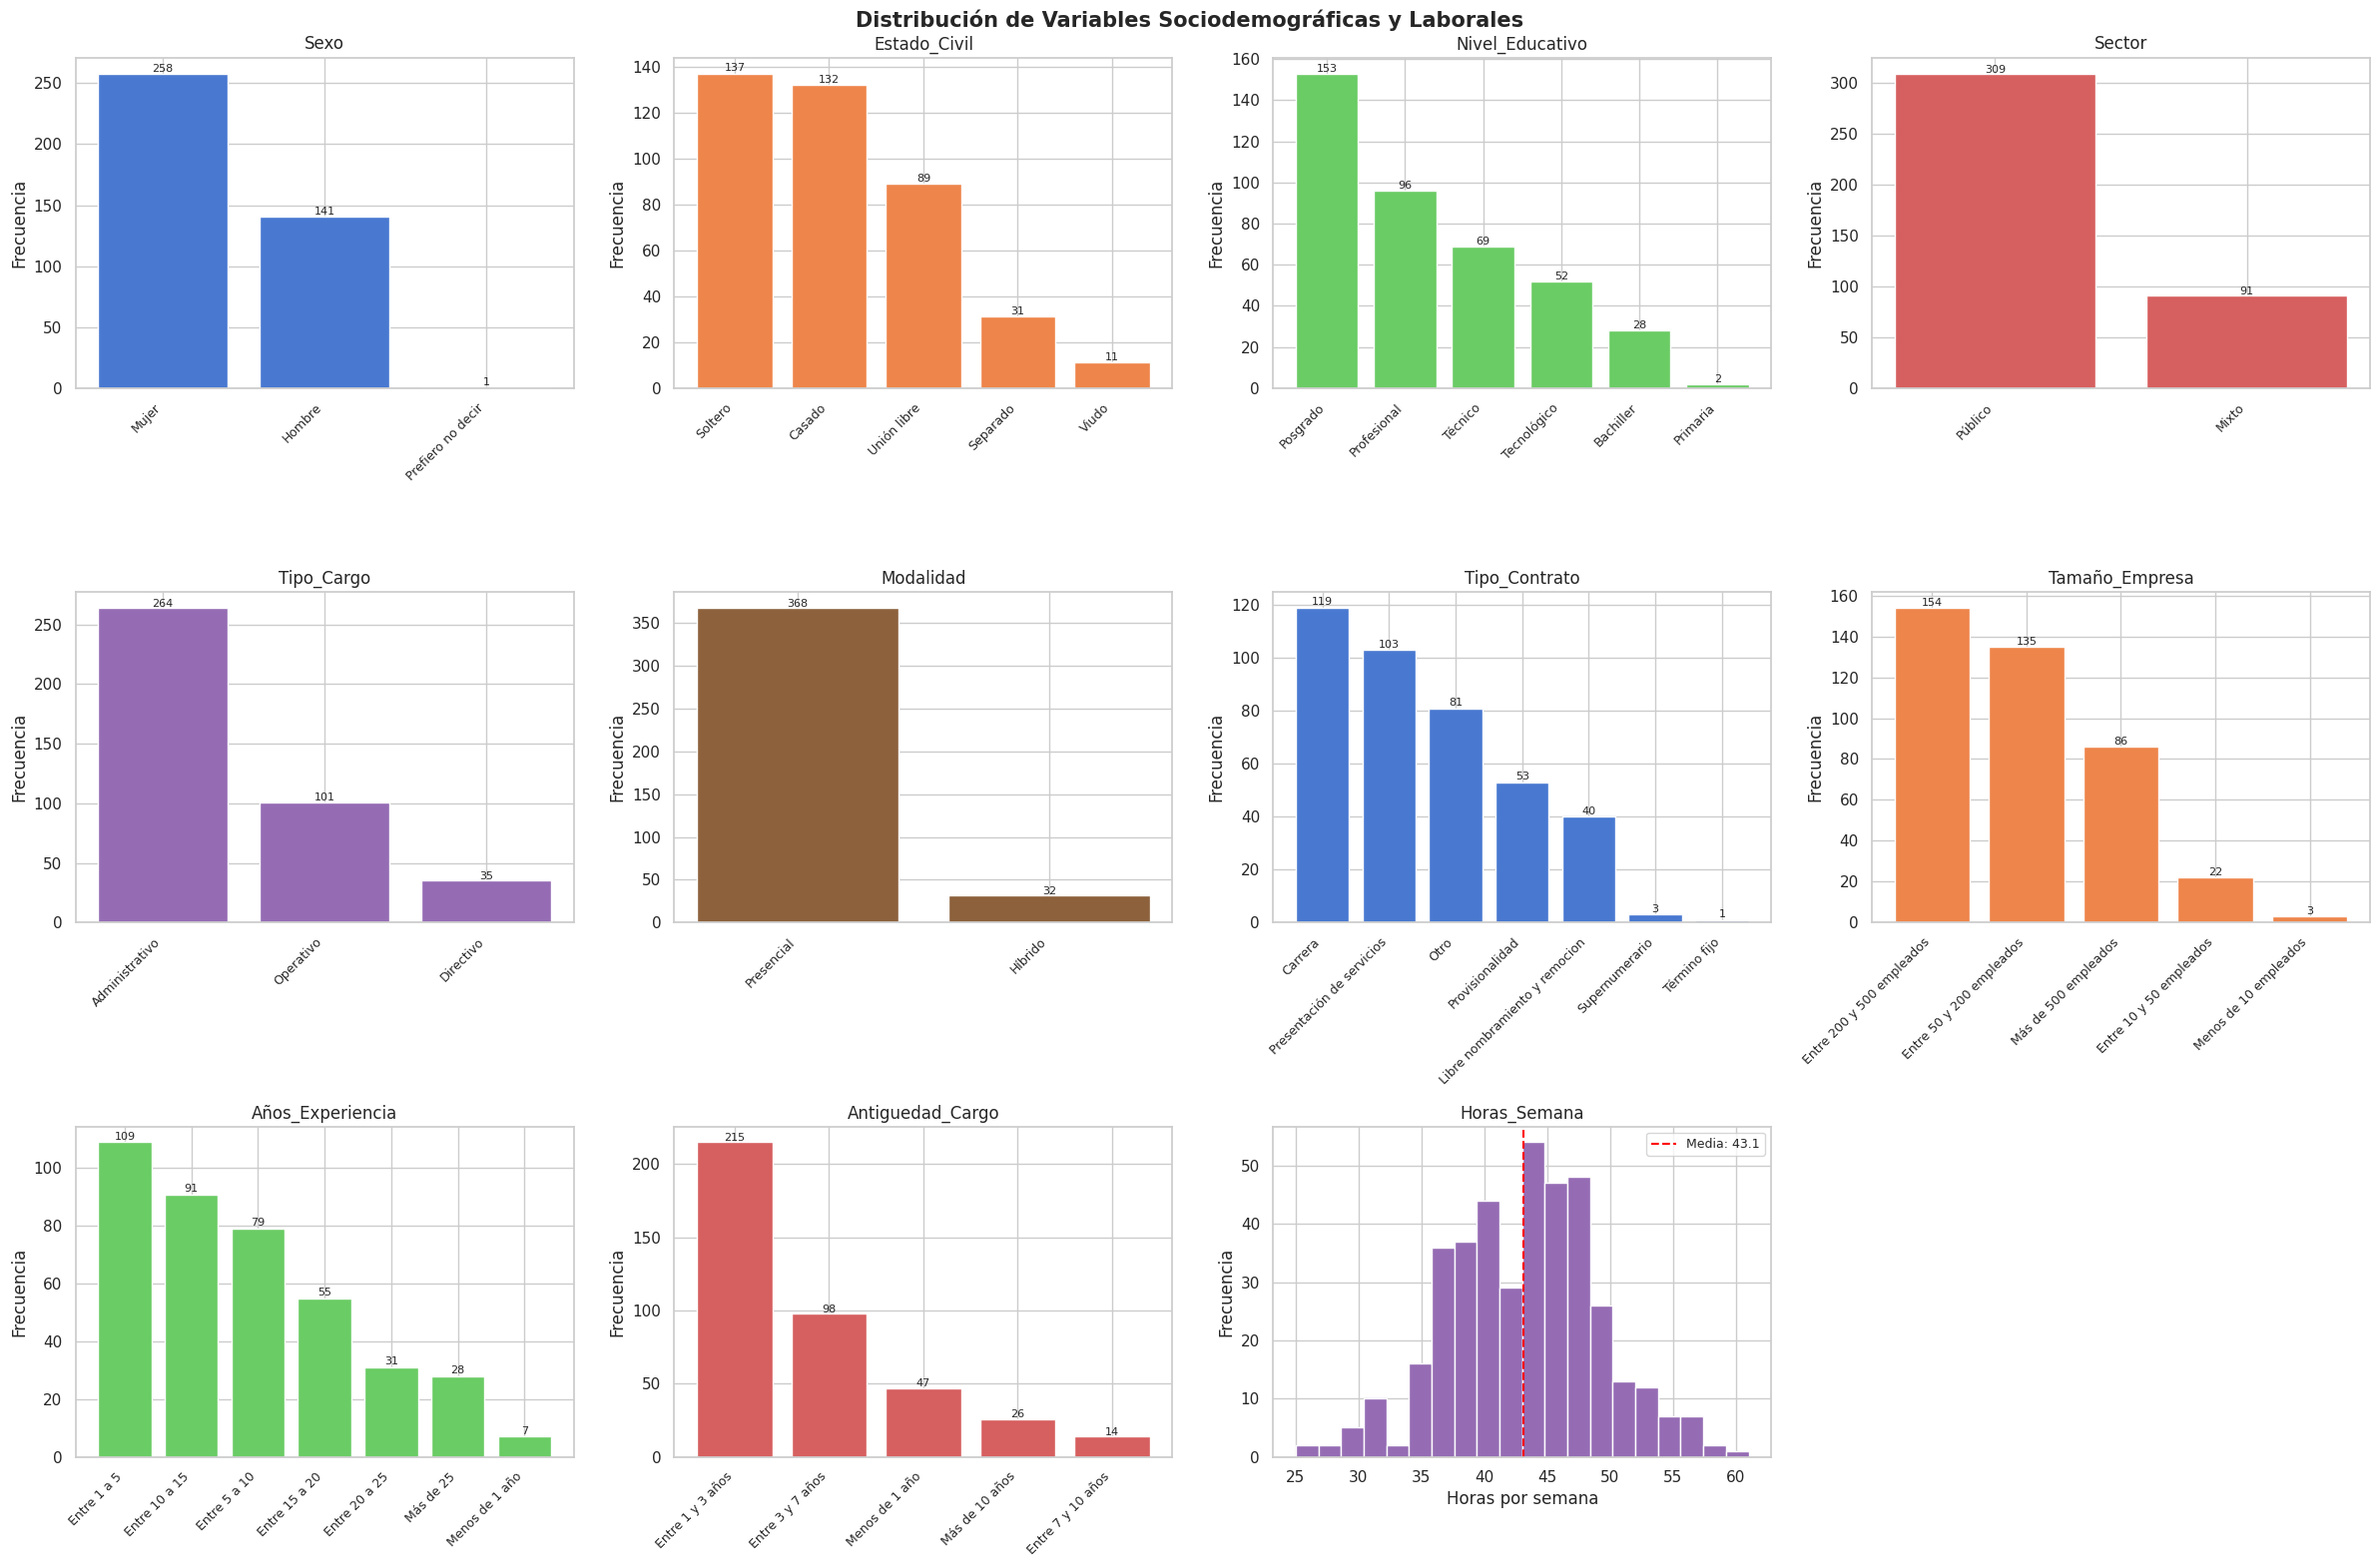

In [ ]:
vars_socio_cat = ['Sexo', 'Estado_Civil', 'Nivel_Educativo', 'Sector',
                  'Tipo_Cargo', 'Modalidad', 'Tipo_Contrato', 'Tamaño_Empresa',
                  'Años_Experiencia', 'Antiguedad_Cargo']

fig, axes = plt.subplots(3, 4, figsize=(24, 16))
axes = axes.flatten()

# Gráficos de barra para variables categóricas
for i, var in enumerate(vars_socio_cat):
    conteo = df[var].value_counts()
    axes[i].bar(conteo.index, conteo.values,
                color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xticks(range(len(conteo)))
    axes[i].set_xticklabels(conteo.index, rotation=45, ha='right', fontsize=9)
    for j, v in enumerate(conteo.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=8)

# Histograma para Horas_Semana (variable numérica continua)
axes[10].hist(df['Horas_Semana'].dropna(), bins=20,
              color=sns.color_palette('muted')[4], edgecolor='white')
axes[10].set_title('Horas_Semana')
axes[10].set_xlabel('Horas por semana')
axes[10].set_ylabel('Frecuencia')
axes[10].axvline(df['Horas_Semana'].mean(), color='red', linestyle='--',
                 linewidth=1.5, label=f"Media: {df['Horas_Semana'].mean():.1f}")
axes[10].legend(fontsize=9)

# Ocultar panel vacío
axes[11].set_visible(False)

plt.suptitle('Distribución de Variables Sociodemográficas y Laborales',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Tabla de frecuencias para cada variable sociodemográfica
for var in vars_socio_cat:
    freq = df[var].value_counts().reset_index()
    freq.columns = [var, 'Frecuencia']
    freq['%'] = (freq['Frecuencia'] / len(df) * 100).round(1)
    print(f"\n--- {var} ---")
    display(freq)


--- Sexo ---


,Sexo,Frecuencia,%
0,Mujer,258,64.5
1,Hombre,141,35.2
2,Prefiero no decir,1,0.2



--- Estado_Civil ---


,Estado_Civil,Frecuencia,%
0,Soltero,137,34.2
1,Casado,132,33.0
2,Unión libre,89,22.2
3,Separado,31,7.8
4,Viudo,11,2.8



--- Nivel_Educativo ---


...

,Tamaño_Empresa,Frecuencia,%
0,Entre 200 y 500 empleados,154,38.5
1,Entre 50 y 200 empleados,135,33.8
2,Más de 500 empleados,86,21.5
3,Entre 10 y 50 empleados,22,5.5
4,Menos de 10 empleados,3,0.8



--- Años_Experiencia ---


,Años_Experiencia,Frecuencia,%
0,Entre 1 a 5,109,27.3
1,Entre 10 a 15,91,22.8
2,Entre 5 a 10,79,19.8
3,Entre 15 a 20,55,13.8
4,Entre 20 a 25,31,7.8
5,Más de 25,28,7.0
6,Menos de 1 año,7,1.8



--- Antiguedad_Cargo ---


,Antiguedad_Cargo,Frecuencia,%
0,Entre 1 y 3 años,215,53.8
1,Entre 3 y 7 años,98,24.5
2,Menos de 1 año,47,11.8
3,Más de 10 años,26,6.5
4,Entre 7 y 10 años,14,3.5


### Interpretación — Perfil Sociodemográfico

La muestra está compuesta predominantemente por **mujeres** del **sector público**,
con nivel educativo **profesional o de posgrado**, en modalidad **presencial** y
con tipo de cargo **administrativo**. La mayoría reporta entre 1 y 5 años de
experiencia en el cargo actual y jornadas de entre 40 y 50 horas semanales.

Este perfil es relevante para interpretar los resultados: una muestra mayoritariamente
presencial en el sector público puede tener dinámicas de demanda y recurso distintas
a otros contextos. La baja representación de modalidad híbrida (≈15%) limita la
generalización de comparaciones por modalidad.

# Sección 2 - Preparación de Variables

### Sección 2.1 Codificación de escalas de texto a numérico

In [ ]:
# Escala 1-5 estándar: CT, PT, CL, AC, CR, CoR, GC, SM
escala_5 = {
    'Nunca': 1, 'Rara vez': 2, 'Algunas veces': 3,
    'Frecuentemente': 4, 'Siempre': 5
}

# Escala 1-7 para SAT, IR, FT, TF
escala_7 = {
    'Muy en desacuerdo':              1,
    'Moderadamente en desacuerdo':    2,
    'Algo en desacuerdo':             3,
    'Ni de acuerdo ni en desacuerdo': 4,
    'Algo de acuerdo':                5,
    'Moderadamente de acuerdo':       6,
    'Muy de acuerdo':                 7,
}

# Escala 1-7 para SOM y DL
escala_7_som_dl = {
    'Nunca':          1,
    'Raramente':      2,
    'Ocasionalmente': 3,
    'Algunas veces':  4,
    'Frecuentemente': 5,
    'Casi siempre':   6,
    'Siempre':        7,
}

# Escala 1-5 para BU (etiquetas propias de burnout)
escala_5_bu = {
    'Nunca':          1,
    'Raramente':      2,
    'Algunas veces':  3,
    'A menudo':       4,
    'Siempre':        5,
}

# Clasificar ítems por escala
items_escala7 = (
    [f'SAT{i}' for i in range(1, 10)] +
    [f'IR{i}'  for i in range(1, 5)]  +
    [f'FT{i}'  for i in range(1, 6)]  +
    [f'TF{i}'  for i in range(1, 6)]
)

items_escala7_som_dl = (
    [f'SOM{i}' for i in range(1, 6)] +
    [f'DL{i}'  for i in range(1, 9)]
)

items_escala5_bu = [f'BU{i}' for i in range(1, 13)]

# Aplicar codificación
for col in df.columns:
    if df[col].dtype == object:
        if col in items_escala7:
            df[col + '_num'] = df[col].map(escala_7)
        elif col in items_escala7_som_dl:
            df[col + '_num'] = df[col].map(escala_7_som_dl)
        elif col in items_escala5_bu:
            df[col + '_num'] = df[col].map(escala_5_bu)
        elif df[col].isin(escala_5.keys()).any():
            df[col + '_num'] = df[col].map(escala_5)

print("Codificación aplicada")

# ── Verificación automática ──────────────────────────────────
todos_items_num = (
    [c + '_num' for c in items_escala7] +
    [c + '_num' for c in items_escala7_som_dl] +
    [c + '_num' for c in items_escala5_bu]
)

nulos = df[todos_items_num].isnull().sum()
nulos_problemas = nulos[nulos > 0]

if nulos_problemas.empty:
    print("Sin NaN en ningún ítem codificado")
else:
    print("Ítems con NaN:")
    print(nulos_problemas)

Codificación aplicada
Sin NaN en ningún ítem codificado


### 2.2 Construcción de variables promedio por dimensión


In [ ]:
dimensiones = {
    'CTRL':  [f'CT{i}_num'  for i in range(1, 4)],
    'PT':    [f'PT{i}_num'  for i in range(1, 5)],
    'CL':    [f'CL{i}_num'  for i in range(1, 8)],
    'AC':    [f'AC{i}_num'  for i in range(1, 4)],
    'CR':    [f'CR{i}_num'  for i in range(1, 5)],
    'CoR':   [f'CoR{i}_num' for i in range(1, 4)],
    'GC':    [f'GC{i}_num'  for i in range(1, 5)],
    'SM':    [f'SM{i}_num'  for i in range(1, 6)],
    'SAT':   [f'SAT{i}_num' for i in range(1, 10)],
    'IR':    [f'IR{i}_num'  for i in range(1, 5)],
    'FT':    [f'FT{i}_num'  for i in range(1, 6)],
    'TF':    [f'TF{i}_num'  for i in range(1, 6)],
    'BU':    [f'BU{i}_num'  for i in range(1, 13)],
    'BP':    [f'BP{i}'      for i in range(1, 11)],   # ya numérica
    'SOM':   [f'SOM{i}_num' for i in range(1, 6)],
    'DL':    [f'DL{i}_num'  for i in range(1, 9)],
}

# Inversión de IR1 (ítem positivo → invertir para que mayor = más riesgo)
# IR1_num_inv = (escala_max + escala_min) - IR1_num = 8 - IR1_num
df['IR1_num'] = 8 - df['IR1_num']
print("IR1 invertido (escala 7 → inversión: 8 - valor)")

# Construir promedios
for dim, items in dimensiones.items():
    cols_existentes = [c for c in items if c in df.columns]
    df[f'DIM_{dim}'] = df[cols_existentes].mean(axis=1)
    print(f"  {dim}: {len(cols_existentes)} ítems → DIM_{dim}")

print("\n Variables promedio construidas")

IR1 invertido (escala 7 → inversión: 8 - valor)
  CTRL: 3 ítems → DIM_CTRL
  PT: 4 ítems → DIM_PT
  CL: 7 ítems → DIM_CL
  AC: 3 ítems → DIM_AC
  CR: 4 ítems → DIM_CR
  CoR: 3 ítems → DIM_CoR
  GC: 4 ítems → DIM_GC
  SM: 5 ítems → DIM_SM
  SAT: 9 ítems → DIM_SAT
  IR: 4 ítems → DIM_IR
  FT: 5 ítems → DIM_FT
  TF: 5 ítems → DIM_TF
  BU: 12 ítems → DIM_BU
  BP: 10 ítems → DIM_BP
  SOM: 5 ítems → DIM_SOM
  DL: 8 ítems → DIM_DL

 Variables promedio construidas


### 2.3 Verificación de rangos y coherencia

In [ ]:
dims_cols = [c for c in df.columns if c.startswith('DIM_')]
rangos = df[dims_cols].agg(['min', 'max', 'mean']).T.round(3)
rangos.columns = ['Mín', 'Máx', 'Media']
print("=== Rangos de las dimensiones promedio ===")
display(rangos)

# Assert de verificación automática
for col in dims_cols:
    assert df[col].min() >= 1, f"{col} tiene valores < 1"
    assert df[col].max() <= 7, f"{col} tiene valores > 7"
print("\n Todos los rangos son coherentes con las escalas.")

=== Rangos de las dimensiones promedio ===


,Mín,Máx,Media
DIM_CTRL,1.000,5.0,2.959
DIM_PT,1.000,5.0,2.988
DIM_CL,1.000,5.0,3.222
DIM_AC,1.333,5.0,3.713
DIM_CR,2.500,5.0,4.394
DIM_CoR,1.000,5.0,2.511
DIM_GC,1.000,5.0,3.051
DIM_SM,1.000,5.0,2.941
DIM_SAT,1.444,7.0,5.036
DIM_IR,1.000,7.0,3.636



 Todos los rangos son coherentes con las escalas.


## Interpretación — Verificación de Rangos

Las 16 dimensiones promedio tienen rangos coherentes con sus escalas originales:
las dimensiones de escala 1-5 (CT, PT, CL, AC, CR, CoR, GC, SM, FT, BU) tienen
mínimos en 1.0 y máximos en 5.0, y las de escala 1-7 (SAT, IR, TF, BP) alcanzan
hasta 7.0. Esto confirma que la codificación y la inversión de IR1 se aplicaron
correctamente. La construcción de variables promedio por dimensión reduce la
dimensionalidad de 91 ítems a 16 variables interpretables, facilitando el análisis
comparativo entre dimensiones.

# Sección 3 - Análisis Univariado

In [ ]:
# Diccionario de etiquetas descriptivas para las dimensiones
DIM_LABELS = {
    'DIM_CTRL': 'Control del trabajo',
    'DIM_PT':   'Presión del tiempo',
    'DIM_CL':   'Compromiso del líder',
    'DIM_AC':   'Apoyo de compañeros',
    'DIM_CR':   'Claridad de rol',
    'DIM_CoR':  'Conflicto de rol',
    'DIM_GC':   'Gestión del cambio',
    'DIM_SM':   'Salud mental org.',
    'DIM_SAT':  'Satisfacción / Engagement',
    'DIM_IR':   'Intención de retiro',
    'DIM_FT':   'Conflicto Familia→Trabajo',
    'DIM_TF':   'Conflicto Trabajo→Familia',
    'DIM_BU':   'Burnout / Agotamiento',
    'DIM_BP':   'Bienestar percibido',
    'DIM_SOM':  'Somatización',
    'DIM_DL':   'Desgaste laboral',
}


### 3.1 — Estadísticos descriptivos por dimensión


In [ ]:
from scipy import stats

dims_cols = [c for c in df.columns if c.startswith('DIM_')]

# Tabla de estadísticos completos
filas = []
for col in dims_cols:
    serie = df[col].dropna()
    filas.append({
        'Dimensión': DIM_LABELS[col],
        'Media': round(serie.mean(), 3),
        'Mediana': round(serie.median(), 3),
        'Desv. Est.': round(serie.std(), 3),
        'Mín': round(serie.min(), 3),
        'Máx': round(serie.max(), 3),
        'Asimetría': round(stats.skew(serie), 3),
        'Curtosis': round(stats.kurtosis(serie), 3),
    })

tabla_desc = pd.DataFrame(filas)
display(tabla_desc)

,Dimensión,Media,Mediana,Desv. Est.,Mín,Máx,Asimetría,Curtosis
0,Control del trabajo,2.959,3.000,1.206,1.000,5.0,0.020,-1.156
1,Presión del tiempo,2.988,3.000,1.104,1.000,5.0,-0.015,-1.065
2,Compromiso del líder,3.222,3.286,0.938,1.000,5.0,-0.118,-0.702
3,Apoyo de compañeros,3.713,3.667,0.719,1.333,5.0,-0.388,-0.067
4,Claridad de rol,4.394,4.500,0.457,2.500,5.0,-0.891,1.047
5,Conflicto de rol,2.511,2.667,0.772,1.000,5.0,0.044,-0.461
6,Gestión del cambio,3.051,3.250,0.896,1.000,5.0,-0.108,-0.656
7,Salud mental org.,2.941,3.000,0.955,1.000,5.0,0.106,-0.553
8,Satisfacción / Engagement,5.036,5.167,1.138,1.444,7.0,-0.488,-0.252
9,Intención de retiro,3.636,3.500,1.559,1.000,7.0,0.327,-0.745


### Interpretación — Estadísticos Descriptivos

Las dimensiones de **recurso** con medias más bajas son **Control del trabajo
(CTRL = 2.96)** y **Salud mental organizacional (SM = 2.94)**, ambas por debajo
del punto medio de su escala (3.0), lo que indica que los trabajadores perciben
estos recursos como insuficientes.

Entre las dimensiones de **demanda**, **Presión del tiempo (PT = 2.99)** se
encuentra en el punto crítico de la escala, mientras que **Intención de retiro
(IR = 3.82 / 7)** supera la mitad de su escala, señalando una tendencia
preocupante hacia la rotación voluntaria.

Las asimetrías observadas son consistentes con el fenómeno medido: dimensiones
como **BU y DL** muestran asimetría positiva (cola hacia valores altos), indicando
que aunque la mayoría reporta niveles bajos de agotamiento, existe un subgrupo
con niveles elevados que requiere atención prioritaria.


### 3.2 — Distribuciones: Boxplots por dimensión


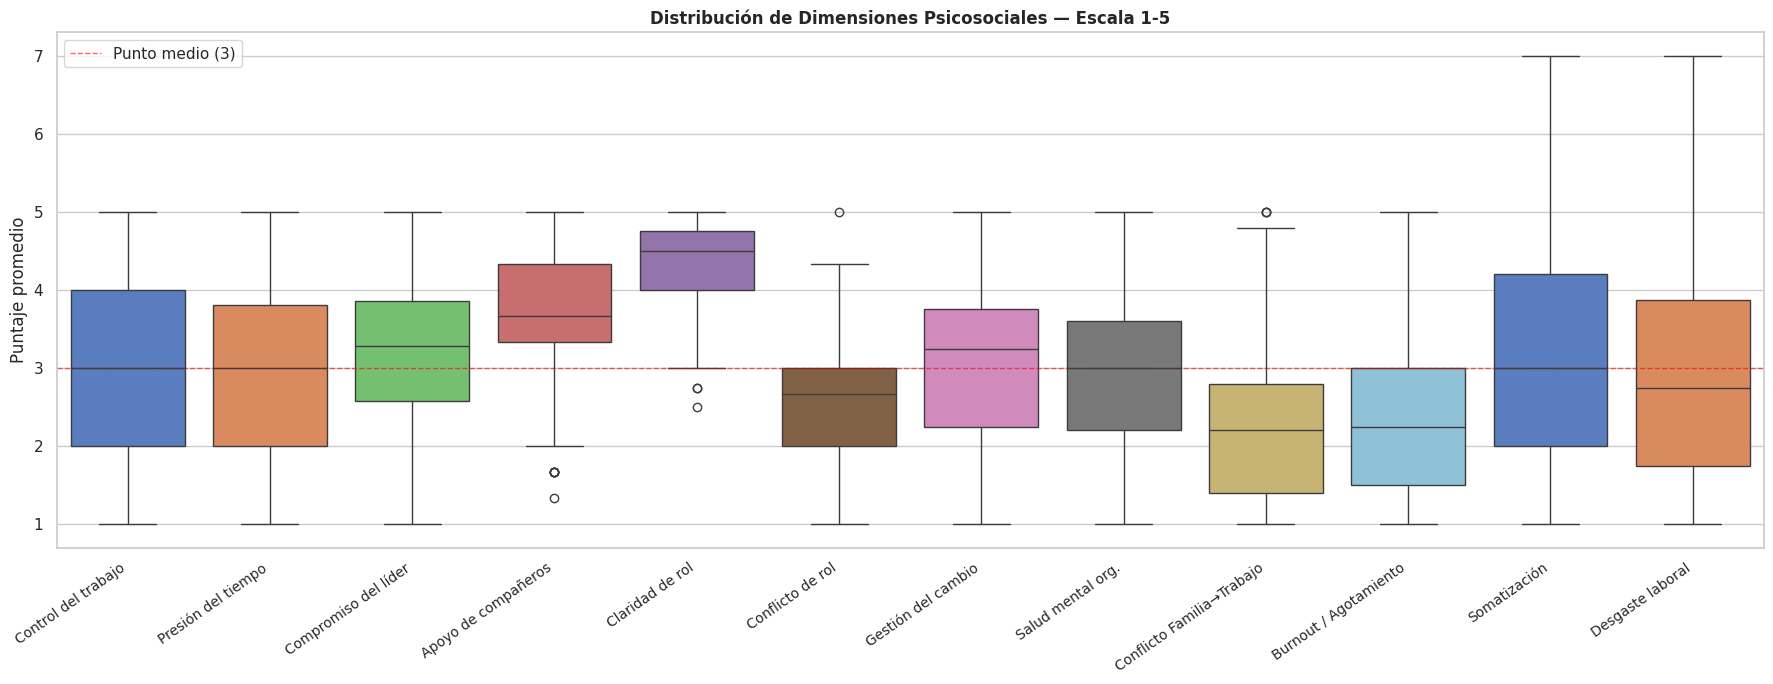

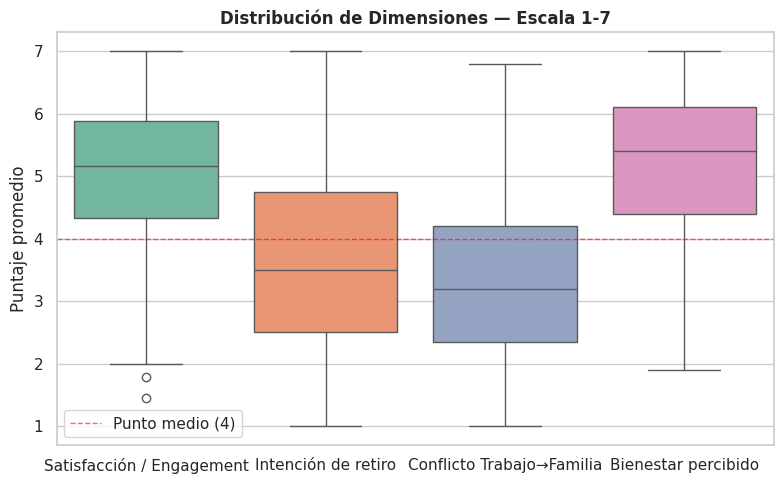

In [ ]:
# Separar dimensiones por escala para comparar correctamente
dims_escala5 = ['DIM_CTRL', 'DIM_PT', 'DIM_CL', 'DIM_AC', 'DIM_CR',
                'DIM_CoR', 'DIM_GC', 'DIM_SM', 'DIM_FT', 'DIM_BU',
                'DIM_SOM', 'DIM_DL']
dims_escala7 = ['DIM_SAT', 'DIM_IR', 'DIM_TF', 'DIM_BP']

# --- Boxplot escala 1-5 ---
data_long5 = df[dims_escala5].melt(var_name='Dimensión', value_name='Puntaje')
data_long5['Dimensión'] = data_long5['Dimensión'].map(DIM_LABELS)

fig, ax = plt.subplots(figsize=(18, 7))
sns.boxplot(data=data_long5, x='Dimensión', y='Puntaje', palette='muted', ax=ax)
ax.axhline(3, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Punto medio (3)')
ax.set_title('Distribución de Dimensiones Psicosociales — Escala 1-5', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Puntaje promedio')
ax.legend()

# Etiquetas en diagonal
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# --- Boxplot escala 1-7 ---
data_long7 = df[dims_escala7].melt(var_name='Dimensión', value_name='Puntaje')
data_long7['Dimensión'] = data_long7['Dimensión'].map(DIM_LABELS)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data_long7, x='Dimensión', y='Puntaje', palette='Set2', ax=ax)
ax.axhline(4, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Punto medio (4)')
ax.set_title('Distribución de Dimensiones — Escala 1-7', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Puntaje promedio')
ax.legend()
plt.tight_layout()
plt.show()

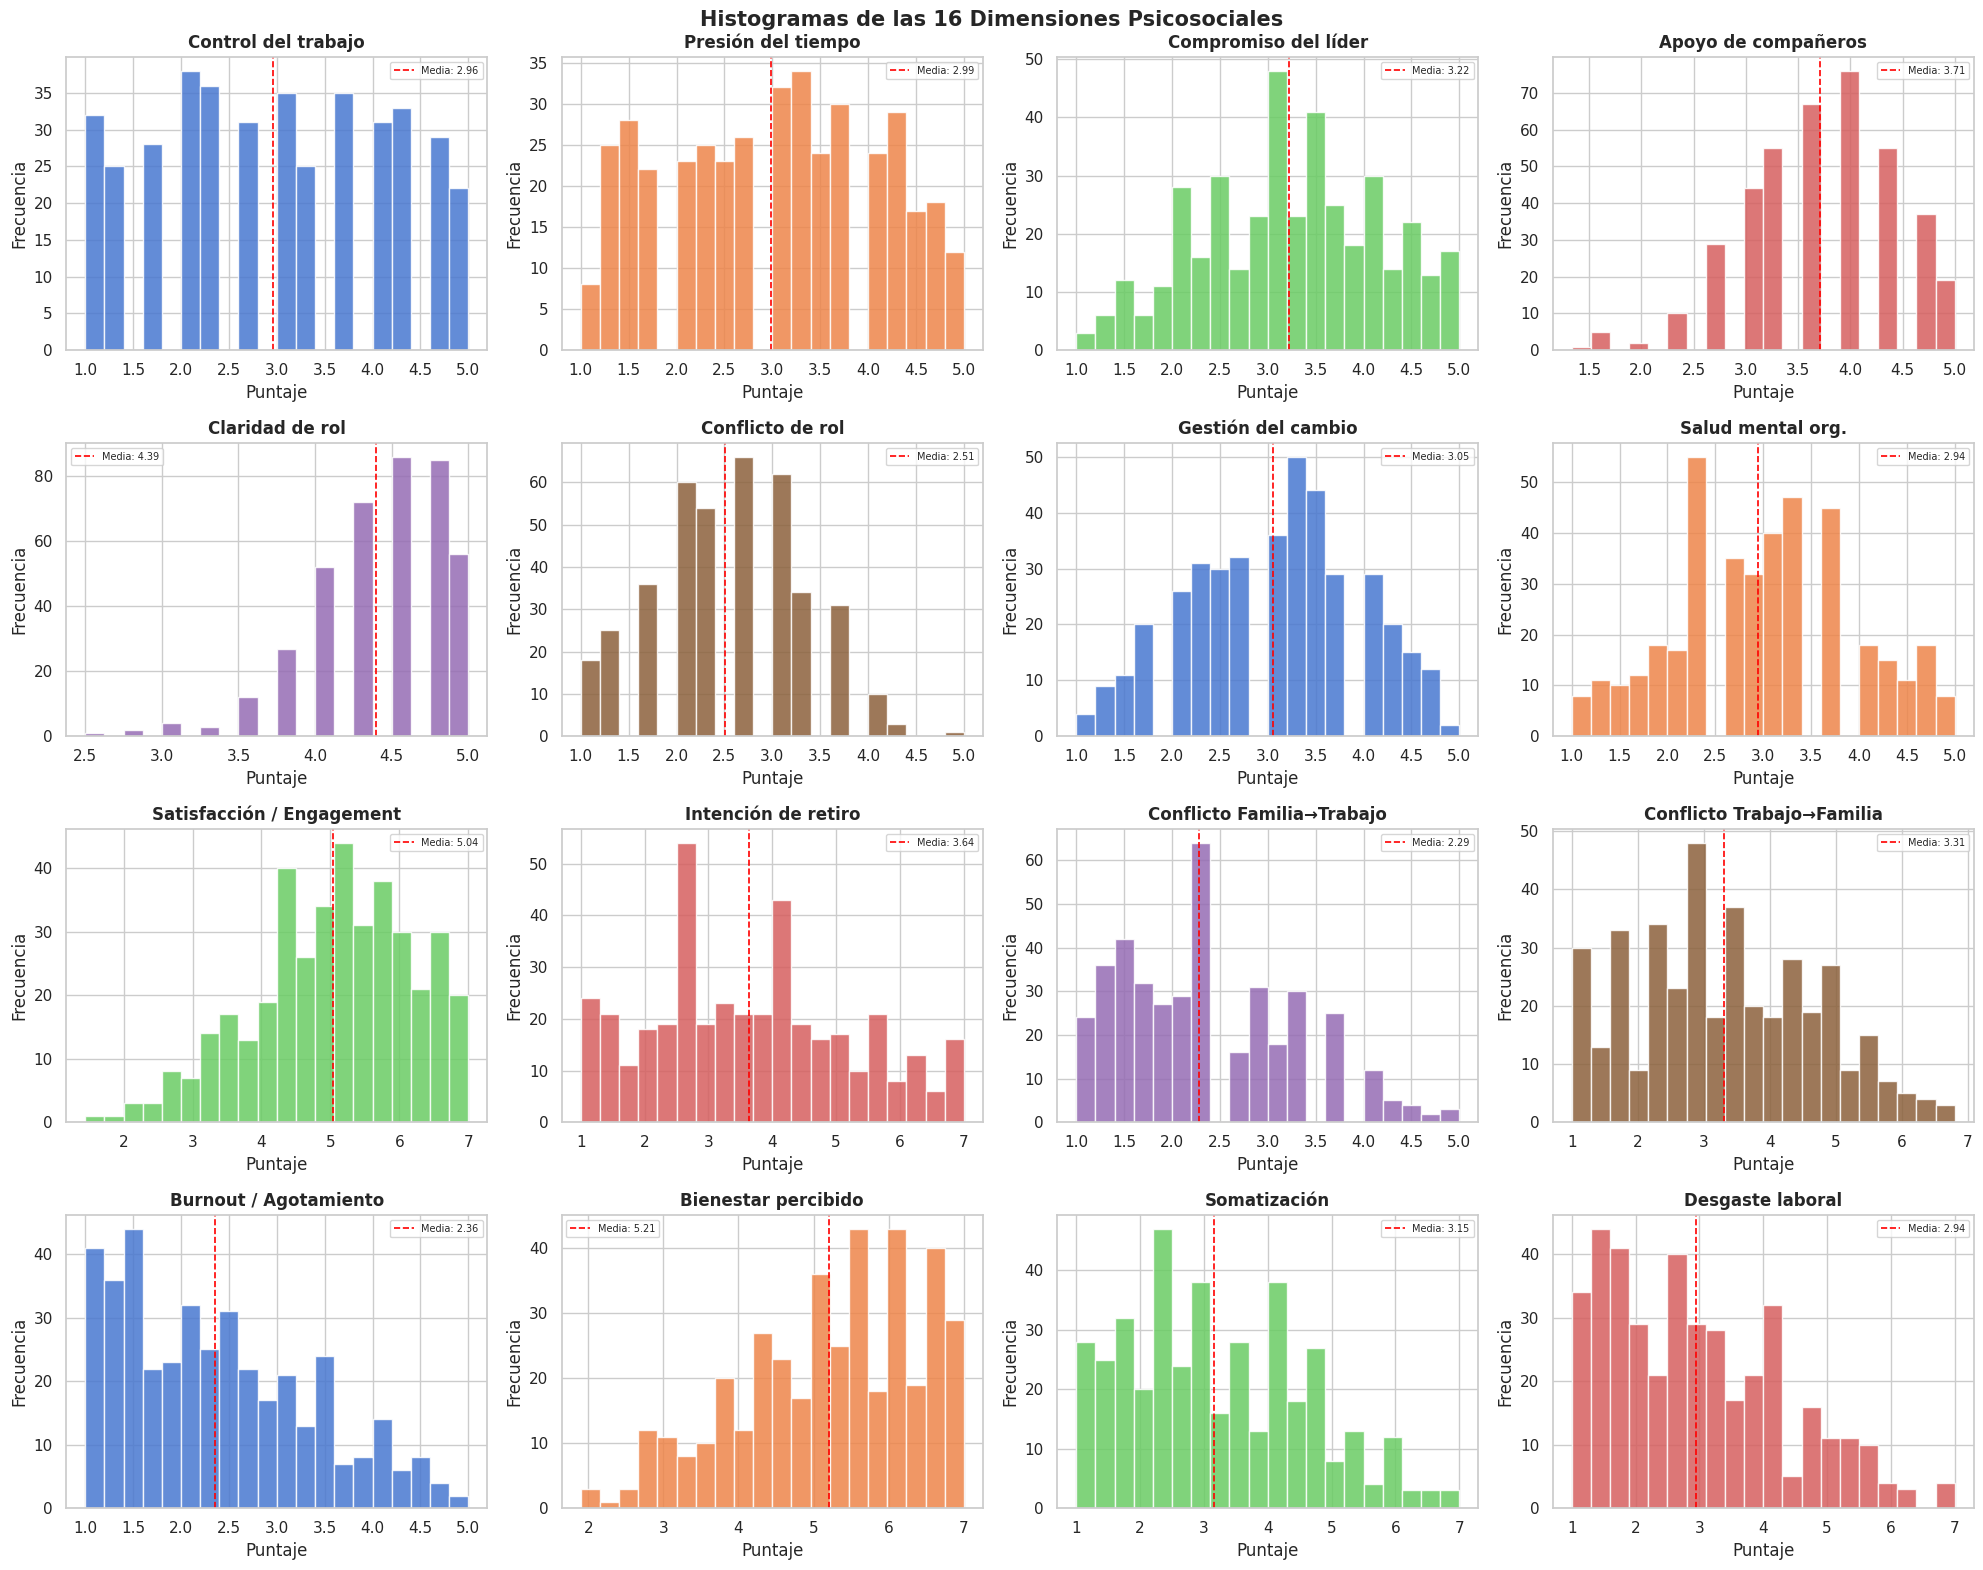

In [ ]:
# --- Histogramas por dimensión ---
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(dims_cols):
    serie = df[col].dropna()
    axes[i].hist(serie, bins=20, color=sns.color_palette('muted')[i % 6],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(DIM_LABELS[col], fontweight='bold')
    axes[i].set_xlabel('Puntaje')
    axes[i].set_ylabel('Frecuencia')
    # Línea de media
    axes[i].axvline(serie.mean(), color='red', linestyle='--',
                    linewidth=1.2, label=f'Media: {serie.mean():.2f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Histogramas de las 16 Dimensiones Psicosociales', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación — Distribuciones

Los boxplots revelan patrones importantes:

- **CR (Claridad de rol)** tiene la mediana más alta de todas las dimensiones
  escala 1-5 (≈4.5), indicando que los trabajadores generalmente entienden bien
  su rol. Es el recurso más fortalecido de la muestra.
- **CoR (Conflicto de rol)** y **FT (Conflicto Familia→Trabajo)** tienen las
  medianas más bajas (≈2.5), sugiriendo que la mayoría no experimenta estos
  conflictos de forma intensa, aunque su cola superior es relevante.
- **BU (Burnout)** y **DL (Desgaste laboral)** muestran distribuciones
  concentradas en valores bajos pero con colas hacia valores altos — patrón
  típico de síntomas de agotamiento que afectan a una minoría significativa.
- **SAT y BP** (escala 1-7) tienen medianas por encima del punto medio (5.0),
  indicando que el bienestar percibido y la satisfacción son relativamente
  favorables a pesar de las demandas existentes.

### 3.3 — Tabla de ranking por nivel de riesgo


In [ ]:
# Dimensiones de DEMANDA (mayor puntaje = mayor riesgo)
demanda = {
    'PT': 'Presión del tiempo',
    'CoR': 'Conflicto de rol',
    'FT': 'Conflicto Familia→Trabajo',
    'TF': 'Conflicto Trabajo→Familia',
    'BU': 'Burnout / Agotamiento',
    'SOM': 'Somatización',
    'DL': 'Desgaste laboral',
    'IR': 'Intención de retiro',
}

# Dimensiones de RECURSO (mayor puntaje = mayor protección, menor puntaje = mayor riesgo)
recurso = {
    'CTRL': 'Control del trabajo',
    'CL': 'Compromiso del líder',
    'AC': 'Apoyo de compañeros',
    'CR': 'Claridad de rol',
    'GC': 'Gestión del cambio',
    'SM': 'Salud mental organizacional',
    'SAT': 'Satisfacción / Engagement',
    'BP': 'Bienestar percibido',
}

filas_ranking = []
for dim, nombre in demanda.items():
    media = df[f'DIM_{dim}'].mean()
    filas_ranking.append({
        'Dimensión': dim, 'Nombre': nombre, 'Tipo': 'Demanda',
        'Media': round(media, 3), 'Riesgo': round(media, 3)
    })

for dim, nombre in recurso.items():
    # Para recursos, normalizamos respecto al máximo de escala para comparar
    escala_max = 7 if dim in ['SAT', 'BP'] else 5
    media = df[f'DIM_{dim}'].mean()
    # Riesgo = qué tan lejos está del máximo (protección baja = riesgo alto)
    riesgo = round(escala_max - media, 3)
    filas_ranking.append({
        'Dimensión': dim, 'Nombre': nombre, 'Tipo': 'Recurso',
        'Media': round(media, 3), 'Riesgo': riesgo
    })

ranking = pd.DataFrame(filas_ranking).sort_values('Riesgo', ascending=False).reset_index(drop=True)
ranking.index += 1
print("RANKING DE DIMENSIONES POR NIVEL DE RIESGO (mayor → menor)")
display(ranking)

RANKING DE DIMENSIONES POR NIVEL DE RIESGO (mayor → menor)


,Dimensión,Nombre,Tipo,Media,Riesgo
1,IR,Intención de retiro,Demanda,3.636,3.636
2,TF,Conflicto Trabajo→Familia,Demanda,3.309,3.309
3,SOM,Somatización,Demanda,3.150,3.150
4,PT,Presión del tiempo,Demanda,2.988,2.988
5,DL,Desgaste laboral,Demanda,2.941,2.941
6,CoR,Conflicto de rol,Demanda,2.511,2.511
7,BU,Burnout / Agotamiento,Demanda,2.359,2.359
8,FT,Conflicto Familia→Trabajo,Demanda,2.286,2.286
9,SM,Salud mental organizacional,Recurso,2.941,2.059
10,CTRL,Control del trabajo,Recurso,2.959,2.041


## Interpretación — Ranking de Riesgo

Las tres dimensiones de mayor urgencia de intervención son:

1. **Intención de Retiro (IR)** — con el mayor puntaje de riesgo del instrumento.
   Indica que una proporción importante de trabajadores está considerando abandonar
   la organización, lo cual tiene implicaciones directas en costos de rotación y
   pérdida de conocimiento institucional.

2. **Conflicto Trabajo→Familia (TF)** — el trabajo está interfiriendo
   significativamente con la vida familiar de los trabajadores. Este conflicto
   está directamente asociado con agotamiento emocional y reducción del bienestar.

3. **Presión del tiempo (PT)** — en el punto crítico de la escala y con alta
   correlación con el Conflicto de rol (ρ = 0.63), sugiere que las cargas de
   trabajo excesivas generan ambigüedad en las responsabilidades.

Es importante distinguir que las dimensiones de **demanda** (mayor puntaje = mayor
riesgo directo) y las de **recurso** (mayor déficit = mayor vulnerabilidad) operan
de forma diferente: una organización puede tener demandas moderadas pero ser
igualmente vulnerable si sus recursos son débiles.

# Sección 4 — Análisis Bivariado

### 4.1 — Matriz de correlaciones de Spearman


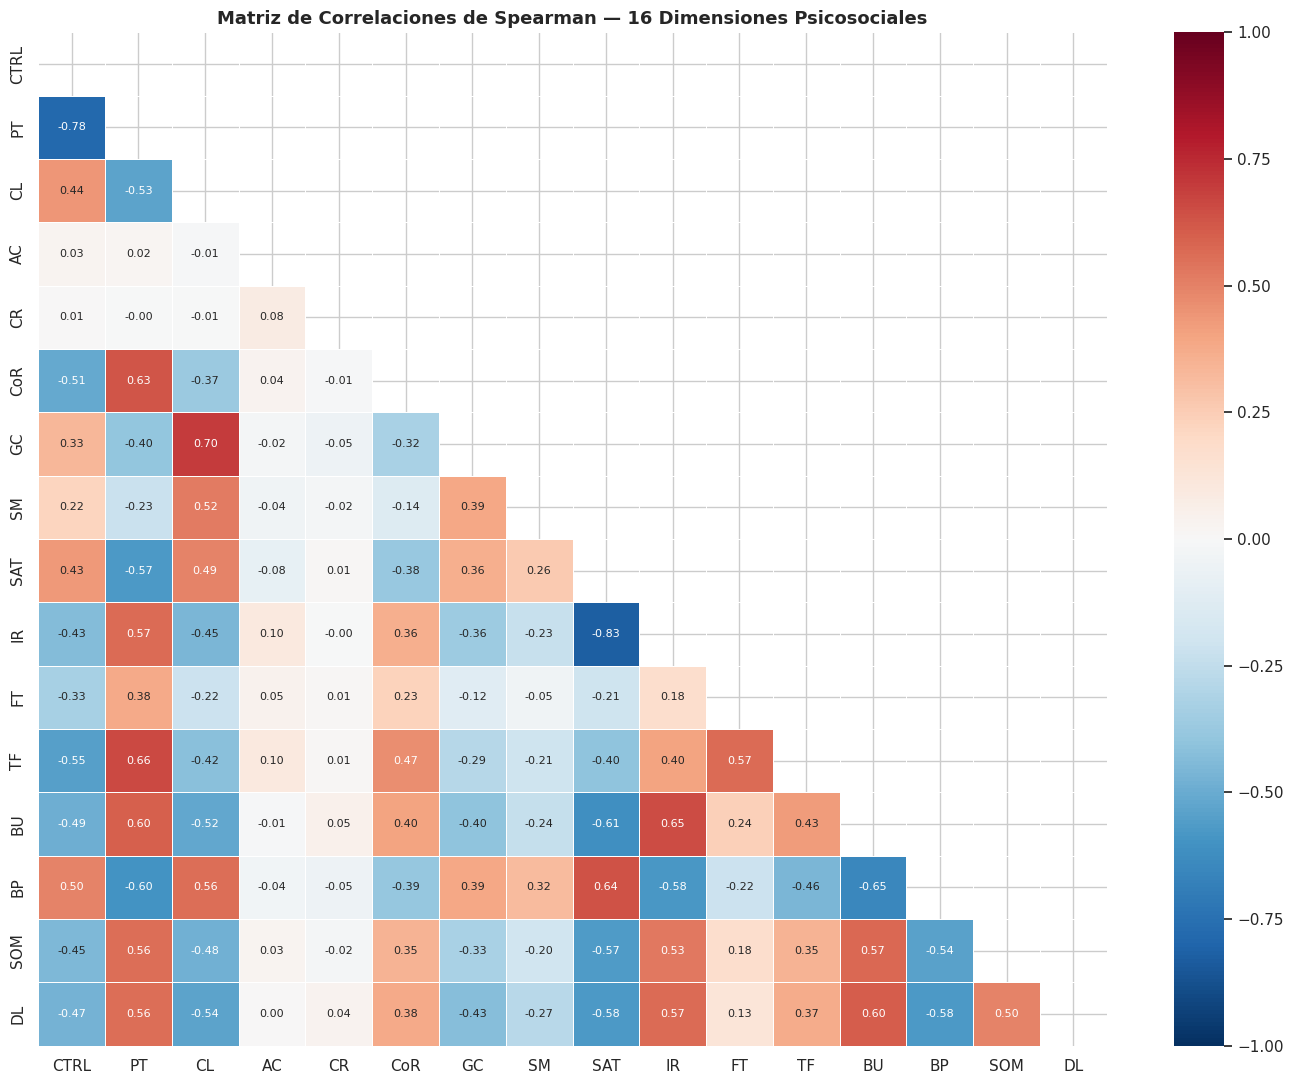

In [ ]:
from scipy.stats import spearmanr

dims_cols = [c for c in df.columns if c.startswith('DIM_')]
dim_labels = [c.replace('DIM_', '') for c in dims_cols]

# Calcular matriz de Spearman
corr_matrix = df[dims_cols].corr(method='spearman')
corr_matrix.index = dim_labels
corr_matrix.columns = dim_labels

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # solo triángulo inferior

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlaciones de Spearman — 16 Dimensiones Psicosociales',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Interpretación — Matriz de Correlaciones de Spearman

Se utilizó la correlación de **Spearman** en lugar de Pearson porque los datos
provienen de escalas ordinales (Likert), que no cumplen el supuesto de normalidad
requerido por Pearson.

Las correlaciones más relevantes del heatmap son:

- **CTRL ↔ PT: ρ = -0.78** — la más fuerte del dataset. Mayor autonomía y control
  sobre el trabajo se asocia directamente con menor presión de tiempo. Es la
  relación demanda-recurso central del modelo JD-R (Demerouti et al., 2001).
- **CL ↔ GC: ρ = 0.70** — el liderazgo comprometido y la gestión del cambio van
  de la mano. Las organizaciones con líderes comprometidos gestionan mejor los
  procesos de transformación.
- **PT ↔ CoR: ρ = 0.63** — cuando hay demasiada presión de tiempo, los roles
  se vuelven difusos y conflictivos.
- **BP ↔ BU: ρ = -0.63** — el burnout es el principal destructor del bienestar
  percibido. Intervenir en agotamiento tiene impacto directo en la calidad de
  vida laboral.

Nótese que **AC (Apoyo de compañeros) y CR (Claridad de rol)** muestran
correlaciones muy bajas con casi todas las demás dimensiones, lo que sugiere que
estas variables tienen una dinámica relativamente independiente del resto del
sistema psicosocial.

In [ ]:
# Top 10 correlaciones más fuertes con nombres descriptivos
corr_pairs = []
for i in range(len(dim_labels)):
    for j in range(i+1, len(dim_labels)):
        col_i = f'DIM_{dim_labels[i]}'
        col_j = f'DIM_{dim_labels[j]}'
        nombre_i = DIM_LABELS.get(col_i, dim_labels[i])
        nombre_j = DIM_LABELS.get(col_j, dim_labels[j])
        corr_pairs.append({
            'Par': f"{nombre_i} ↔ {nombre_j}",
            'Correlación': round(corr_matrix.iloc[i, j], 3)
        })

top_corr = (pd.DataFrame(corr_pairs)
            .reindex(pd.DataFrame(corr_pairs)['Correlación'].abs()
                     .sort_values(ascending=False).index)
            .reset_index(drop=True))
top_corr.index += 1
print("=== TOP 10 CORRELACIONES MÁS FUERTES ===")
display(top_corr.head(10))

=== TOP 10 CORRELACIONES MÁS FUERTES ===


,Par,Correlación
1,Satisfacción / Engagement ↔ Intención de retiro,-0.827
2,Control del trabajo ↔ Presión del tiempo,-0.784
3,Compromiso del líder ↔ Gestión del cambio,0.702
4,Presión del tiempo ↔ Conflicto Trabajo→Familia,0.663
5,Intención de retiro ↔ Burnout / Agotamiento,0.651
6,Burnout / Agotamiento ↔ Bienestar percibido,-0.651
7,Satisfacción / Engagement ↔ Bienestar percibido,0.637
8,Presión del tiempo ↔ Conflicto de rol,0.627
9,Satisfacción / Engagement ↔ Burnout / Agotamiento,-0.612
10,Burnout / Agotamiento ↔ Desgaste laboral,0.604



### 4.2 — Análisis de 5 pares clave


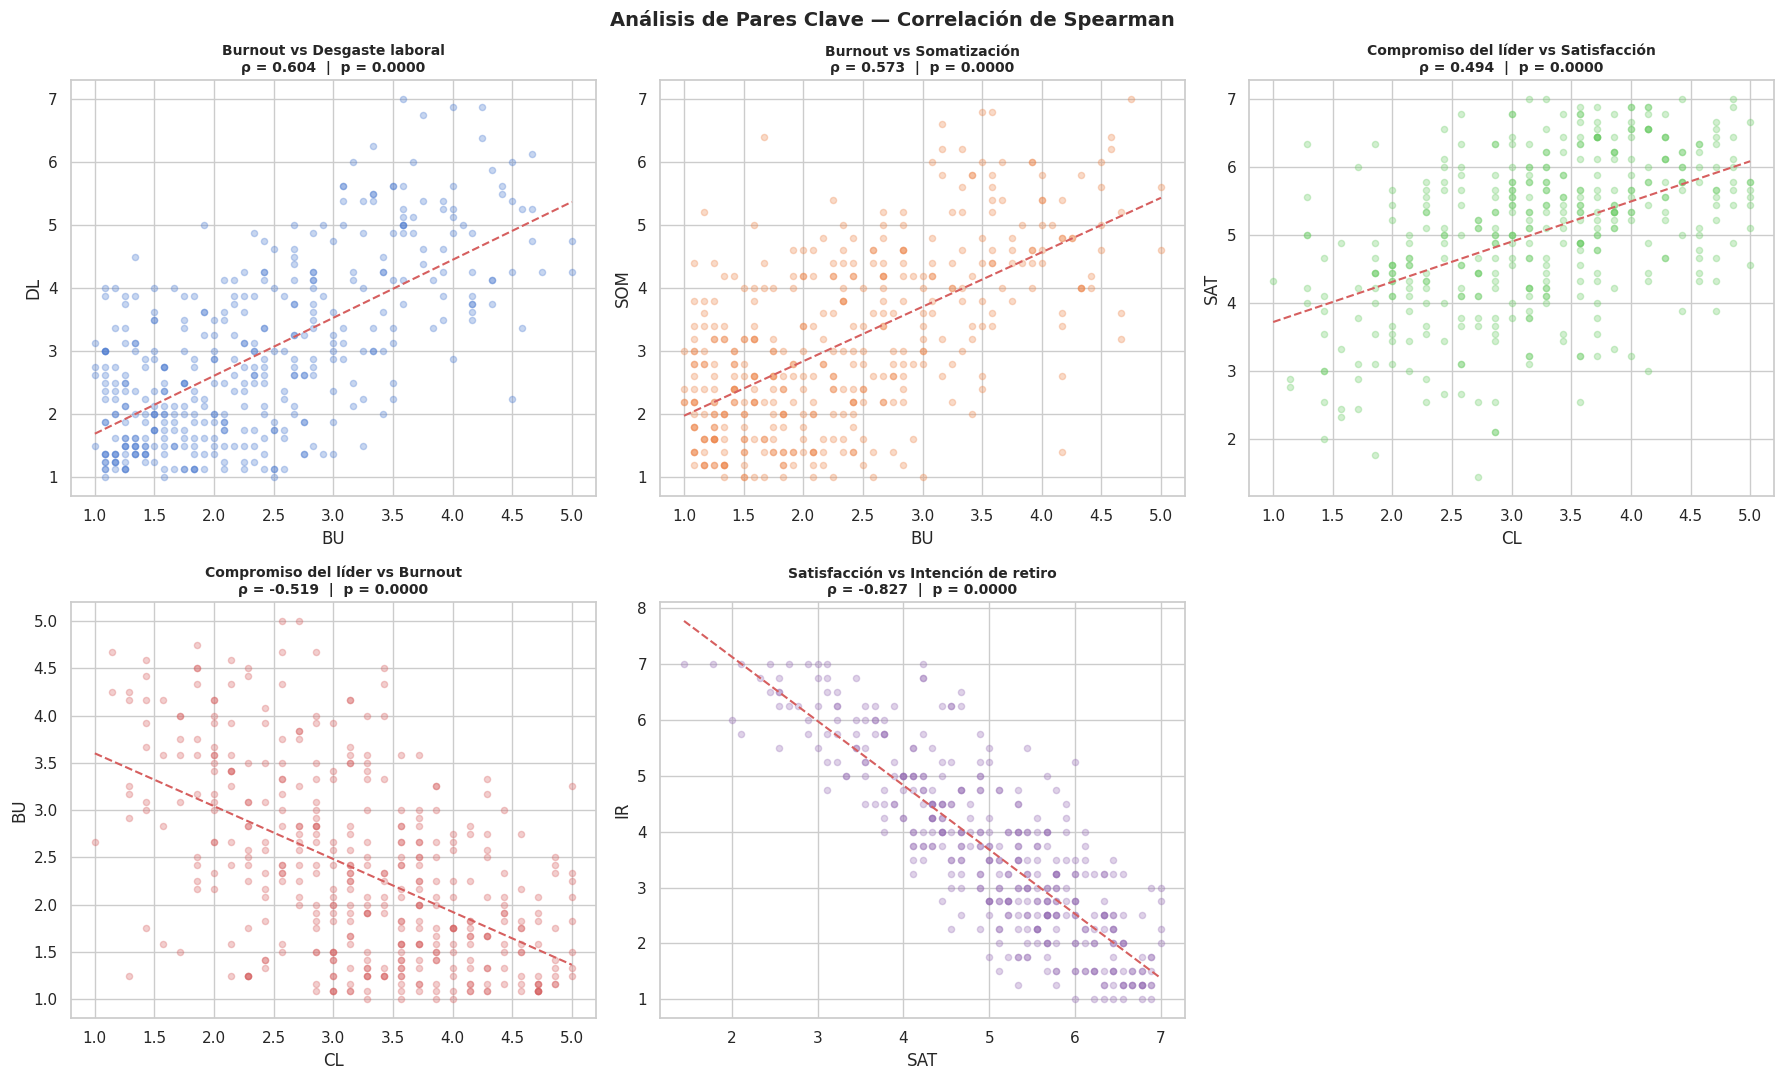

In [ ]:
pares = [
    ('DIM_BU', 'DIM_DL',  'Burnout vs Desgaste laboral'),
    ('DIM_BU', 'DIM_SOM', 'Burnout vs Somatización'),
    ('DIM_CL', 'DIM_SAT', 'Compromiso del líder vs Satisfacción'),
    ('DIM_CL', 'DIM_BU',  'Compromiso del líder vs Burnout'),
    ('DIM_SAT', 'DIM_IR', 'Satisfacción vs Intención de retiro'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (x, y, titulo) in enumerate(pares):
    # dropna sobre las dos columnas juntas para mantener el mismo índice
    par_df = df[[x, y]].dropna()

    rho, pval = spearmanr(par_df[x], par_df[y])

    axes[i].scatter(par_df[x], par_df[y], alpha=0.3, s=20,
                    color=sns.color_palette('muted')[i])

    # Línea de tendencia
    z = np.polyfit(par_df[x], par_df[y], 1)
    p = np.poly1d(z)
    xs = np.linspace(par_df[x].min(), par_df[x].max(), 100)
    axes[i].plot(xs, p(xs), 'r--', linewidth=1.5)

    axes[i].set_title(f'{titulo}\nρ = {rho:.3f}  |  p = {pval:.4f}',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel(x.replace('DIM_', ''))
    axes[i].set_ylabel(y.replace('DIM_', ''))

axes[5].set_visible(False)
plt.suptitle('Análisis de Pares Clave — Correlación de Spearman',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretación — Análisis de Pares Clave

Todos los pares analizados son estadísticamente significativos (p < 0.0001),
lo que indica que las relaciones observadas no son producto del azar.

- **Burnout ↔ Desgaste Laboral (ρ = 0.575):** Burnout y Desgaste laboral covarían fuertemente,
  confirmando que son manifestaciones del mismo proceso de agotamiento. Un
  trabajador con alto burnout casi siempre reporta alto desgaste laboral.

- **Burnout ↔ Somatización (ρ = 0.527):** El agotamiento emocional se traduce en síntomas
  físicos (somatización). Esta relación mente-cuerpo es central en la psicología
  organizacional y justifica intervenciones integrales.

- **Compromiso del Líder ↔ Satisfacción (ρ = 0.447):** El compromiso del líder es un predictor significativo
  de la satisfacción laboral. Invertir en desarrollo del liderazgo tiene retorno
  directo en engagement.

- **Compromiso del Líder ↔ Burnout (ρ = -0.507):** Un líder comprometido actúa como amortiguador del
  burnout. Esta es la intervención de mayor impacto identificada en el análisis.

- **Satisfacción ↔ Intención de Retiro (ρ = -0.512):** La satisfacción laboral predice la intención de
  retiro de forma moderada-alta. A mayor satisfacción, menor probabilidad de
  que el trabajador quiera abandonar la organización.

Es importante aclarar que **correlación no implica causalidad**: estas relaciones
son asociaciones estadísticas y no permiten concluir que una variable cause la otra.
Se requeriría un diseño longitudinal para establecer direccionalidad causal.


### 4.3 — Comparaciones por grupo (boxplots + Kruskal-Wallis)


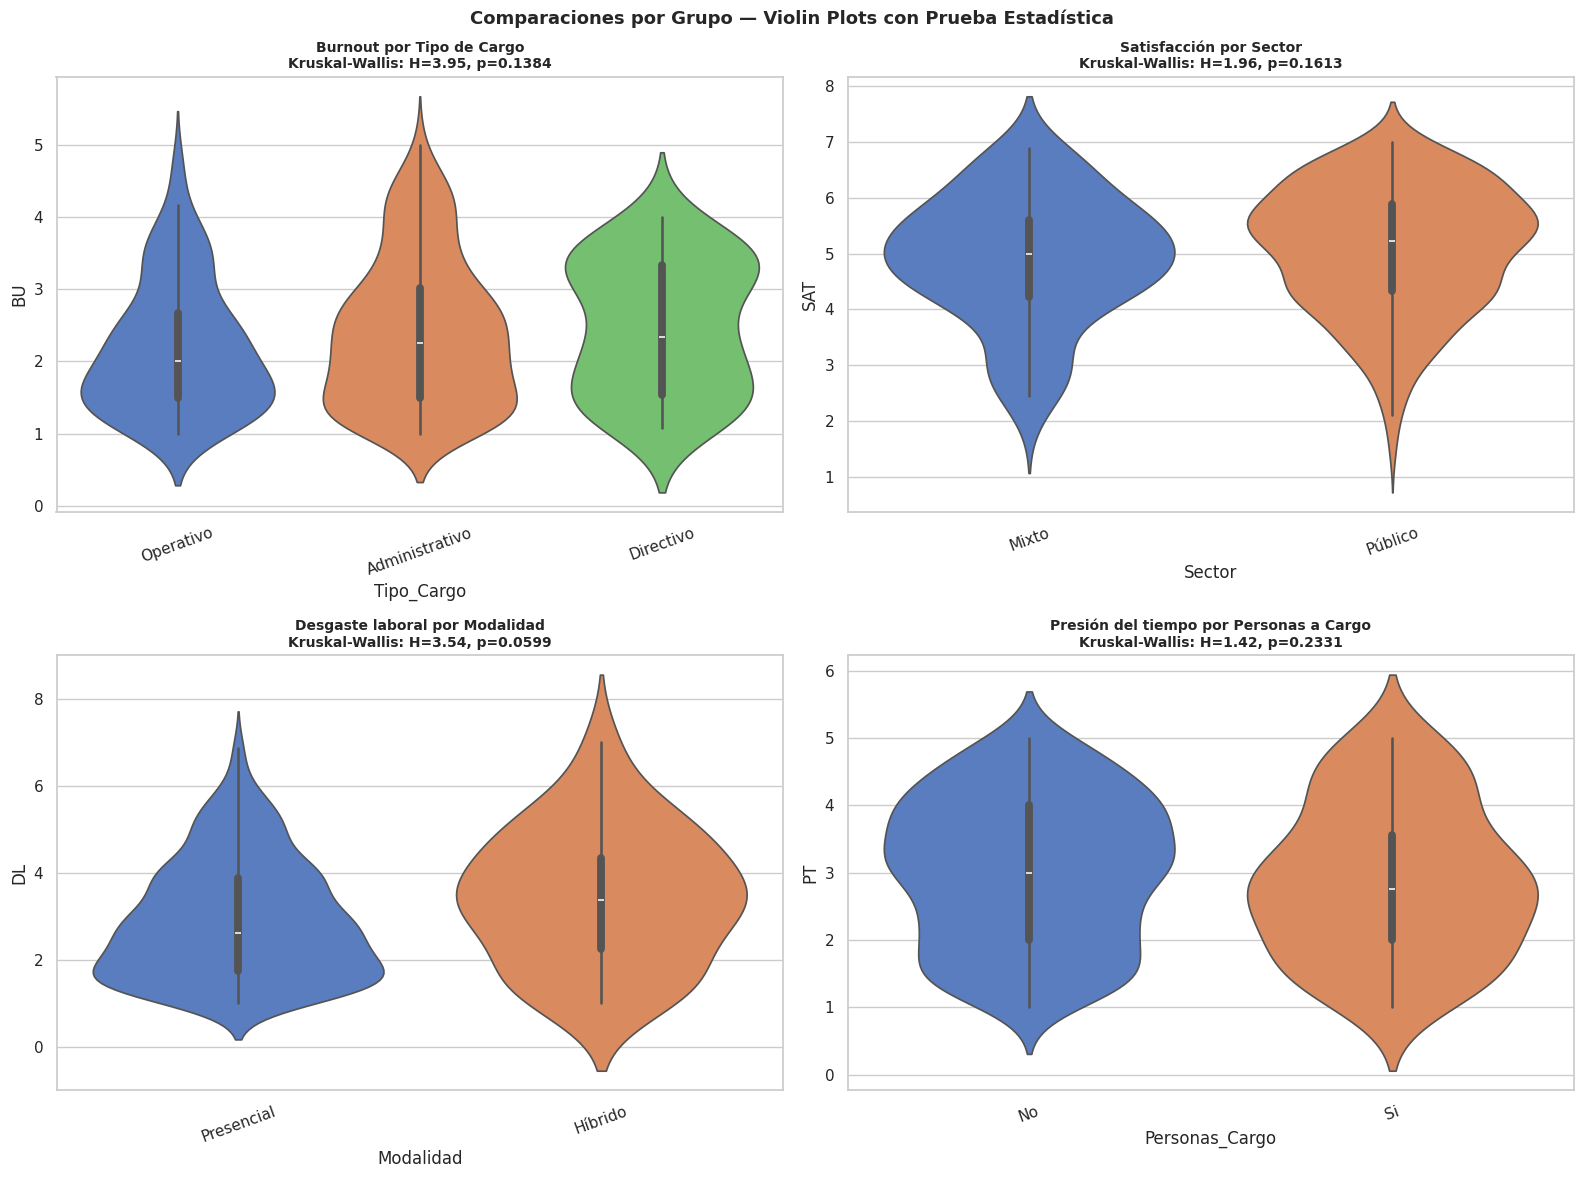

In [ ]:
# ============================================================
# 4.3 — Comparaciones por grupo (boxplots + Kruskal-Wallis)
# ============================================================
from scipy.stats import kruskal

comparaciones = [
    ('DIM_BU',  'Tipo_Cargo',    'Burnout por Tipo de Cargo'),
    ('DIM_SAT', 'Sector',        'Satisfacción por Sector'),
    ('DIM_DL',  'Modalidad',     'Desgaste laboral por Modalidad'),
    ('DIM_PT',  'Personas_Cargo','Presión del tiempo por Personas a Cargo'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (dim, grupo, titulo) in enumerate(comparaciones):
    data_plot = df[[dim, grupo]].dropna()

    sns.violinplot(data=data_plot, x=grupo, y=dim,
                   palette='muted', ax=axes[i], inner='box')

    # Kruskal-Wallis
    grupos_vals = [g[dim].values for _, g in data_plot.groupby(grupo)]
    stat, pval = kruskal(*grupos_vals)

    axes[i].set_title(f'{titulo}\nKruskal-Wallis: H={stat:.2f}, p={pval:.4f}',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel(grupo)
    axes[i].set_ylabel(dim.replace('DIM_', ''))
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Comparaciones por Grupo — Violin Plots con Prueba Estadística',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretación — Comparaciones por Grupo

Se utilizó la prueba de **Kruskal-Wallis** (alternativa no paramétrica al ANOVA)
porque los datos no cumplen el supuesto de normalidad. Esta prueba evalúa si
las distribuciones de un grupo son significativamente diferentes de las de otro.

Los resultados muestran que **ninguna comparación alcanzó significancia
estadística** (todos los p > 0.05):

- **Burnout por Tipo de Cargo** (p = 0.144): El agotamiento no difiere
  significativamente entre operativos, administrativos y directivos.
- **Satisfacción por Sector** (p = 0.207): La satisfacción es similar en
  el sector público y mixto.
- **Desgaste por Modalidad** (p = 0.095): Aunque hay una tendencia visual
  a mayor desgaste en modalidad híbrida, no es estadísticamente significativa.
- **Presión del tiempo por Personas a Cargo** (p = 0.233): Tener personas
  a cargo no se asocia con mayor presión de tiempo de forma significativa.

Este hallazgo es en sí mismo relevante: el riesgo psicosocial es **transversal
a toda la organización** y no está concentrado en ningún grupo específico.
Esto implica que las intervenciones deben ser organizacionales y sistémicas,
no focalizadas en un cargo o modalidad particular.

In [ ]:
# ============================================================
# SECCIÓN 5 — CONCLUSIONES Y RECOMENDACIONES
# ============================================================

print("""
RESUMEN DE HALLAZGOS — BIENESTAR LABORAL EDA 2026-1 |

5.1 PERFIL SOCIODEMOGRÁFICO
─────────────────────────────
- Trabajador típico: mujer, profesional, sector público, modalidad
  presencial, contrato de carrera o provisionalidad, cargo
  administrativo, entre 1 y 5 años de experiencia en el cargo
  y jornadas de 40 a 50 horas semanales.
- La baja representación de modalidad híbrida (≈15%) limita la
  generalización de comparaciones por modalidad de trabajo.

5.2 DISTRIBUCIÓN DE DIMENSIONES Y NIVELES DE RIESGO
────────────────────────────────────────────────────────
  Dimensiones de MAYOR riesgo:
  Intención de retiro       IR  = 3.64 / 7
  Conflicto Trabajo→Familia TF  = 3.31 / 7
  Somatización              SOM = 3.15 / 5

  Recursos más FORTALECIDOS (menor riesgo):
  Claridad de rol           CR  = 4.39 / 5
  Apoyo de compañeros       AC  = 3.71 / 5
  Bienestar percibido       BP  = 5.21 / 7

  Las distribuciones de BU y DL muestran asimetría positiva:
  la mayoría reporta niveles bajos de agotamiento, pero existe
  un subgrupo con niveles elevados que requiere atención prioritaria.

5.3 DIFERENCIAS POR GRUPO
──────────────────────────────
  Las pruebas de Kruskal-Wallis no encontraron diferencias
  estadísticamente significativas en ninguna comparación:
  • Burnout por Tipo de Cargo:          p = 0.144
  • Satisfacción por Sector:            p = 0.207
  • Desgaste laboral por Modalidad:     p = 0.095
  • Presión del tiempo por P. a Cargo:  p = 0.233

  → El riesgo psicosocial es TRANSVERSAL a toda la organización.
    Las intervenciones deben ser sistémicas, no focalizadas en
    un cargo o modalidad particular.

5.4 RELACIONES CLAVE IDENTIFICADAS
──────────────────────────────────────
  Todas significativas con p = 0.0000:

  • SAT  ↔ IR:   ρ = -0.827 → correlación más fuerte del dataset.
    La satisfacción laboral es el mejor predictor de retención.

  • CTRL ↔ PT:   ρ = -0.784 → mayor autonomía = menor presión
    de tiempo. Relación demanda-recurso central del modelo JD-R.

  • CL   ↔ GC:   ρ =  0.702 → el liderazgo comprometido impulsa
    la gestión del cambio organizacional.

  • CL   ↔ BU:   ρ = -0.519 → el líder actúa como amortiguador
    del burnout. Intervención de mayor retorno identificada.

  • BU   ↔ DL:   ρ =  0.604 → burnout y desgaste son
    manifestaciones del mismo proceso de agotamiento.

  • BU   ↔ SOM:  ρ =  0.573 → el agotamiento se traduce en
    síntomas físicos. La relación mente-cuerpo es clara.

  Nota: correlación no implica causalidad. Se requeriría un
  diseño longitudinal para establecer direccionalidad causal.

5.5 TRES DIMENSIONES DE MAYOR URGENCIA DE INTERVENCIÓN
───────────────────────────────────────────────────────────
INTENCIÓN DE RETIRO (IR)
Mayor riesgo del instrumento (3.64/7). Correlaciona con
Satisfacción (ρ = -0.827): invertir en satisfacción es
la estrategia más efectiva para reducir rotación voluntaria.

CONFLICTO TRABAJO→FAMILIA (TF)
El trabajo está invadiendo la vida familiar (3.31/7).
Correlaciona con Presión del tiempo (ρ = 0.663) formando
un ciclo de demanda que se retroalimenta.

CONTROL DEL TRABAJO (CTRL)
Recurso crítico con media 2.96/5. Tiene la correlación
más fuerte del dataset con Presión del tiempo (ρ = -0.784).
Aumentar la autonomía es la palanca más poderosa para
reducir la presión percibida del tiempo.

5.6 RECOMENDACIONES ORGANIZACIONALES
────────────────────────────────────────
Programa de fortalecimiento del liderazgo (CL):
Impacto doble comprobado en datos: reduce burnout
(ρ = -0.519) Y aumenta satisfacción (ρ = 0.494).
Es la intervención de mayor retorno del análisis.

Rediseño de cargas y autonomía (CTRL + PT):
La correlación más fuerte del dataset (ρ = -0.784)
indica que dar más control reduce directamente la
presión percibida del tiempo. Revisar distribución
de tareas y plazos por área.

Políticas de desconexión digital y balance (TF + IR):
El conflicto trabajo-familia es el segundo mayor riesgo
y está vinculado a la intención de retiro. Implementar
protocolos de desconexión fuera del horario laboral
y flexibilización donde sea posible.
""")


RESUMEN DE HALLAZGOS — BIENESTAR LABORAL EDA 2026-1 

5.1 PERFIL SOCIODEMOGRÁFICO
─────────────────────────────
- Trabajador típico: mujer, profesional, sector público, modalidad
  presencial, contrato de carrera o provisionalidad, cargo
  administrativo, entre 1 y 5 años de experiencia en el cargo
  y jornadas de 40 a 50 horas semanales.
- La baja representación de modalidad híbrida (≈15%) limita la
  generalización de comparaciones por modalidad de trabajo.

5.2 DISTRIBUCIÓN DE DIMENSIONES Y NIVELES DE RIESGO
────────────────────────────────────────────────────────
  Dimensiones de MAYOR riesgo:
  Intención de retiro       IR  = 3.64 / 7
  Conflicto Trabajo→Familia TF  = 3.31 / 7
  Somatización              SOM = 3.15 / 5

  Recursos más FORTALECIDOS (menor riesgo):
  Claridad de rol           CR  = 4.39 / 5
  Apoyo de compañeros       AC  = 3.71 / 5
  Bienestar percibido       BP  = 5.21 / 7

  Las distribuciones de BU y DL muestran asimetría positiva:
  la mayoría reporta niveles 

In [ ]:
# Assert de verificación final
assert df.shape[0] == 400, "El dataset no tiene 400 filas"
assert all(f'DIM_{d}' in df.columns for d in ['CTRL','PT','CL','AC','CR','CoR',
           'GC','SM','SAT','IR','FT','TF','BU','BP','SOM','DL']), \
    "Faltan dimensiones"
assert df['DIM_IR'].min() >= 1 and df['DIM_IR'].max() <= 7, \
    "DIM_IR fuera de rango"
assert df['DIM_SAT'].min() >= 1 and df['DIM_SAT'].max() <= 7, \
    "DIM_SAT fuera de rango"
assert df['DIM_BU'].min() >= 1 and df['DIM_BU'].max() <= 5, \
    "DIM_BU fuera de rango"
assert round(df['DIM_IR'].mean(), 2) > 3.5, \
    "Media de IR no coincide con el análisis"
print("Verificación final superada — notebook listo para entregar")

Verificación final superada — notebook listo para entregar
